# Clasificación de Textos Históricos por Década — Entrega 2 (Deep Learning)

## Aprendizaje de Máquina 2026-10
### Universidad de los Andes · Departamento de Ingeniería de Sistemas y Computación
**Grupo 11** — Diego Molano · Andrés Cáceres

---

## Enfoque general

**Tarea (3. del enunciado):** dado un párrafo en español histórico (siglos XVI–XIX, con fuerte
ruido de OCR), predecir la **década** en que fue escrito. Son **39 clases ordinales** (etiquetas
150…188; p.ej. 157 = 1570–1579), balanceadas (~805 ejemplos/clase).

**Modelo final = híbrido de dos señales descorrelacionadas:**

1. **Componente DL (principal):** un *ensemble multi-task* de transformers
   preentrenados y fine-tuneados — `xlm-roberta-large` + `BETO` + `xlm-roberta-base` — con doble
   cabeza (década + siglo). Aporta **señal semántica densa** y aprovecha la transferencia de
   aprendizaje obligatoria.
2. **Componente clásico (red de seguridad):** el TF-IDF char_wb + word de la Entrega 1
   (Kaggle 0.296). Es **robusto al ruido OCR por construcción** (`esta`/`eſta` comparten
   n-gramas de caracteres) — una señal que el encoder subword no capta igual.

Se combinan con `p = blend(p_dl, p_legacy)`, calibrado en un **holdout** estratificado. Como el
barrido incluye "solo legacy", **el híbrido nunca puntúa por debajo del clásico** → piso garantizado.

**Resultado:** holdout F1-macro **0.3383**, Kaggle público **0.33810**.

> **Nota de reproducibilidad / eficiencia:** este notebook **no reentrena**. Reutiliza los modelos
> ya fine-tuneados (guardados como `state_dict` + tokenizer) y el clásico cacheado; solo hace
> inferencia + ensemble. Por eso corre en ~17 min en Kaggle (T4) en vez de las ~horas del
> entrenamiento. El notebook es **autocontenido**: todas las utilidades (preprocesamiento, modelo,
> métricas) están definidas más abajo, sin dependencias de módulos externos del proyecto.

## 0. Dependencias e importaciones

Mismas versiones que entrenaron los modelos (transformers 4.45.x) para recargar los `state_dict`
sin sorpresas. En Kaggle, descomenta el `%pip install` la primera vez.


In [1]:
# %pip install -q transformers==4.45.* safetensors sentencepiece scikit-learn==1.5.* joblib

import os, sys, re, random, json, unicodedata, warnings
from pathlib import Path
from dataclasses import dataclass

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import joblib
import torch
from transformers import AutoTokenizer, AutoConfig, AutoModel
import torch.nn as nn

print("CUDA:", torch.cuda.is_available(),
      "| device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")


CUDA: True | device: Tesla T4


### Utilidades inlineadas (1/3) — semillas, normalización OCR y etiquetas

In [2]:
SEED = 42
NUM_DECADES = 39
DECADE_MIN, DECADE_MAX = 150, 188
NUM_CENTURIES = 4


def set_global_seed(seed=SEED):
    '''Reproducibilidad: fija las semillas de random / numpy / torch.'''
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# --- Normalización de ruido OCR (heredada de la Entrega 1) ---
# Sustituye glifos OCR-corruptos / históricos por su equivalente moderno antes de tokenizar.
OCR_MAP = {
    "ſ": "s", "ﬅ": "st", "ﬆ": "st",                              # s-larga
    "æ": "ae", "œ": "oe", "ß": "ss",                              # ligaduras
    "ﬁ": "fi", "ﬂ": "fl", "ﬃ": "ffi", "ﬄ": "ffl",
    "ã": "an", "õ": "on", "ũ": "un", "ẽ": "en", "ĩ": "in",        # tildes nasales (abreviaturas)
    "ꝓ": "pro", "ꝑ": "per", "ꝗ": "que",                          # abreviaturas latinas medievales
    "ç": "c", "Ç": "C",
    "–": "-", "—": "-", "―": "-", "¬": "",                        # guiones
    "‘": "'", "’": "'", "“": '"', "”": '"', "«": '"', "»": '"',   # comillas
}
_OCR_PATTERN = re.compile("|".join(re.escape(k) for k in OCR_MAP))


def normalize_ocr(text):
    if not isinstance(text, str):
        return ""
    return _OCR_PATTERN.sub(lambda m: OCR_MAP[m.group()], text)


def preprocess_for_transformer(text):
    '''Limpieza MÍNIMA para encoders subword (RoBERTa/XLM-R): NFKC + OCR + colapsa espacios.
    Preserva casing, dígitos y puntuación: son señal histórica que el tokenizer aprovecha.'''
    if not isinstance(text, str):
        return ""
    t = unicodedata.normalize("NFKC", text)
    t = normalize_ocr(t).replace("\n", " ").replace("\t", " ")
    return re.sub(r"\s+", " ", t).strip()


# --- Etiquetas: década <-> índice <-> siglo ---
DECADE_TO_IDX = {d: i for i, d in enumerate(range(DECADE_MIN, DECADE_MAX + 1))}
IDX_TO_DECADE = {i: d for d, i in DECADE_TO_IDX.items()}
CENTURY_TO_IDX = {16: 0, 17: 1, 18: 2, 19: 3}


def decade_to_century(decade):
    '''157 -> 16 (siglo XVI), 180 -> 19 (siglo XIX).'''
    return (int(decade) * 10 // 100) + 1


set_global_seed(SEED)
print("Utilidades base listas. Décadas:", NUM_DECADES, "| siglos:", NUM_CENTURIES)


Utilidades base listas. Décadas: 39 | siglos: 4


### Utilidades inlineadas (2/3) — carga del corpus, split, métricas y submission

In [3]:
@dataclass
class Corpus:
    train: pd.DataFrame
    eval_: pd.DataFrame

    @property
    def y_train_idx(self):
        return np.array([DECADE_TO_IDX[d] for d in self.train["decade"].values])


def load_corpus(data_dir):
    '''Carga train.csv / eval.csv y aplica la limpieza mínima (columna text_clean).'''
    data_dir = Path(data_dir)
    train = pd.read_csv(data_dir / "train.csv")
    eval_ = pd.read_csv(data_dir / "eval.csv")
    train["text_clean"] = train["text"].apply(preprocess_for_transformer)
    eval_["text_clean"] = eval_["text"].apply(preprocess_for_transformer)
    return Corpus(train=train, eval_=eval_)


def quick_summary(corpus):
    print("Train:", corpus.train.shape, "| Eval:", corpus.eval_.shape)
    counts = corpus.train["decade"].value_counts()
    print("Décadas únicas:", corpus.train["decade"].nunique(),
          "| rango:", corpus.train["decade"].min(), "-", corpus.train["decade"].max())
    print(f"Ejemplos por clase  min/mean/max: {counts.min()} / {counts.mean():.1f} / {counts.max()}")
    nw = corpus.train["text"].str.split().str.len()
    print(f"Palabras por texto  median/p95/max: {nw.median():.0f} / {nw.quantile(0.95):.0f} / {nw.max()}")


def stratified_split(corpus, val_size=0.10, seed=SEED):
    '''Holdout estratificado por década. Con seed=42 produce el split CANÓNICO que comparten
    todos los modelos del proyecto (holdout limpio = sin fuga al reusar modelos ya entrenados).'''
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(corpus.train))
    return train_test_split(idx, test_size=val_size,
                            stratify=corpus.train["decade"].values, random_state=seed)


def compute_metrics(y_true, y_pred):
    '''Métricas sobre índices 0..38. Además del F1-macro (métrica del concurso) reporta la
    distancia ORDINAL en décadas y el error inter-siglo, claves para diagnosticar el modelo.'''
    from sklearn.metrics import f1_score, accuracy_score
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    td = np.vectorize(IDX_TO_DECADE.__getitem__)(y_true)
    pdc = np.vectorize(IDX_TO_DECADE.__getitem__)(y_pred)
    dist = np.abs(td - pdc)
    ct = np.array([decade_to_century(d) for d in td])
    cp = np.array([decade_to_century(d) for d in pdc])
    return {
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "mean_decade_dist": float(dist.mean()),
        "within_1_decade": float((dist <= 1).mean()),
        "within_2_decades": float((dist <= 2).mean()),
        "inter_century_err": float((ct != cp).mean()),
    }


def print_metrics(m, label=""):
    p = f"[{label}] " if label else ""
    print(f"{p}F1-macro {m['f1_macro']:.4f} | acc {m['accuracy']:.4f} | dist {m['mean_decade_dist']:.2f} "
          f"| <=1dec {m['within_1_decade']*100:.1f}% | <=2dec {m['within_2_decades']*100:.1f}% "
          f"| inter-siglo {m['inter_century_err']*100:.1f}%")


def write_submission(ids, decade_preds, out_path):
    '''Escribe submission en formato Kaggle (id, answer).'''
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"id": list(ids), "answer": list(decade_preds)}).to_csv(out_path, index=False)
    return out_path


print("Carga / split / métricas listas.")


Carga / split / métricas listas.


### Utilidades inlineadas (3/3) — limpieza TF-IDF y features de estilo (componente clásico)

> **Decisión clave:** el TF-IDF NO usa la misma limpieza que el transformer. El encoder subword
> rinde mejor con casing/dígitos/puntuación intactos; el TF-IDF de palabras/chars rinde mejor con
> minúsculas + sin dígitos. Estas funciones reproducen la limpieza que dio **0.296** en la Entrega 1.


In [4]:
# Stopwords mínimas (español + latín funcional). NO es la lista completa de NLTK: se conservan
# palabras de función con evolución temporal (señal de época).
STOPWORDS_TFIDF = {
    "de", "la", "el", "los", "las", "que", "en", "y", "por", "con", "para", "del",
    "se", "su", "sus", "como", "mas", "muy", "sin", "sobre", "entre", "desde", "hasta",
    "et", "est", "non", "sed", "cum", "aut", "vel", "qui", "quod", "quia", "enim",
    "sunt", "esse", "nec", "inter", "ante", "post", "super", "sub", "apud",
    "autem", "nam", "ergo", "tamen",
}
_TFIDF_WORD_KEEP = re.compile(r"[^a-záéíóúüñ\s]")
_REPEAT_RUN = re.compile(r"(.)\1{3,}")
_DIGITS = re.compile(r"\d+")


def clean_for_tfidf_words(text):
    '''TF-IDF de PALABRAS: minúsculas + sin dígitos + solo letras (con acentos/ñ) + sin stopwords.
    Sin stemming: formas históricas como "auia", "efta", "vueftra" son señal temporal.'''
    if not isinstance(text, str):
        return ""
    t = normalize_ocr(unicodedata.normalize("NFKC", text)).lower()
    t = t.replace("\n", " ").replace("\t", " ")
    t = _TFIDF_WORD_KEEP.sub(" ", _DIGITS.sub(" ", t))
    return " ".join(w for w in t.split() if len(w) > 2 and w not in STOPWORDS_TFIDF)


def clean_for_tfidf_chars(text):
    '''TF-IDF de CARACTERES (char_wb): minúsculas + sin dígitos + compresión de repeticiones.
    Robusto al OCR: "esta"/"eſta" comparten n-gramas de caracteres tras normalizar.'''
    if not isinstance(text, str):
        return ""
    t = normalize_ocr(unicodedata.normalize("NFKC", text)).lower()
    t = t.replace("\n", " ").replace("\t", " ")
    t = _REPEAT_RUN.sub(r"\1\1", _DIGITS.sub(" ", t))
    return re.sub(r"\s+", " ", t).strip()


_PUNCT = re.compile(r"[.,;:!?¡¿\"'()\[\]{}«»]")
_ACCENTED = re.compile(r"[áéíóúüñ]", re.IGNORECASE)


def numeric_style_feats(texts):
    '''7 features de estilo con variación temporal (medidas sobre el texto crudo):
    [log #chars, log #words, long. media palabra, diversidad léxica (TTR),
     ratio puntuación, ratio acentos, ratio mayúsculas]. Escalar antes de concatenar.'''
    rows = []
    for t in texts:
        s = t if isinstance(t, str) else ""
        nch = len(s)
        toks = s.split()
        nw = len(toks)
        awl = float(np.mean([len(w) for w in toks])) if toks else 0.0
        ttr = (len(set(w.lower() for w in toks)) / nw) if nw else 0.0
        alpha = sum(c.isalpha() for c in s)
        rows.append([np.log1p(nch), np.log1p(nw), awl, ttr,
                     len(_PUNCT.findall(s)) / nch if nch else 0.0,
                     len(_ACCENTED.findall(s)) / alpha if alpha else 0.0,
                     sum(c.isupper() for c in s) / alpha if alpha else 0.0])
    return np.asarray(rows, dtype=np.float32)


print("Limpieza TF-IDF + features de estilo listas.")


Limpieza TF-IDF + features de estilo listas.


### Utilidades inlineadas (DL) — modelo multi-task e inferencia con ventana deslizante

> **Importante (compatibilidad):** la clase `MultiTaskClassifier` y los nombres de sus capas
> (`encoder`, `head_decade`, `head_century`) deben coincidir EXACTAMENTE con los que entrenaron y
> guardaron el `state_dict.pt`; por eso esta parte se conserva idéntica a la del entrenamiento.


In [5]:
def masked_mean_pool(last_hidden_state, attention_mask):
    '''Mean-pool sobre tokens reales (ignora padding). Más robusto que el CLS crudo cuando el
    pooler preentrenado no viene bien calibrado (XLM-R).'''
    mask = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


class MultiTaskClassifier(nn.Module):
    '''Encoder preentrenado + cabeza década (39) + cabeza siglo (4, opcional).

    El siglo es una señal "fácil" que estabiliza la representación compartida (multi-task).
    pretrained=False reconstruye solo la arquitectura desde config (los pesos llegan vía
    load_state_dict al recargar un modelo ya entrenado).'''

    def __init__(self, model_name, num_decades=NUM_DECADES, num_centuries=NUM_CENTURIES,
                 dropout=0.1, use_century=True, pretrained=True):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name) if pretrained \
            else AutoModel.from_config(self.config)
        hidden = self.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.head_decade = nn.Linear(hidden, num_decades)
        self.use_century = use_century
        self.head_century = nn.Linear(hidden, num_centuries) if use_century else None

    def forward(self, input_ids, attention_mask=None, **_unused):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(masked_mean_pool(out.last_hidden_state, attention_mask))
        logits_dec = self.head_decade(pooled)
        logits_cen = self.head_century(pooled) if self.use_century else None
        return logits_dec, logits_cen


def make_token_windows(input_ids, max_length=384, stride=128, special_tokens=2):
    '''Ventanas de tokens con solapamiento para textos largos (>max_length).'''
    content_max = max_length - special_tokens
    if len(input_ids) <= content_max:
        return [input_ids]
    windows, start = [], 0
    while start < len(input_ids):
        end = min(start + content_max, len(input_ids))
        windows.append(input_ids[start:end])
        if end == len(input_ids):
            break
        start += content_max - (special_tokens + stride if stride else 0)
        if start < 0:
            start = 0
    return windows


def load_multitask(model_dir, use_century=True, device=None):
    '''Reconstruye un MultiTaskClassifier desde un bundle guardado (config.json + state_dict.pt)
    y carga los pesos. El encoder se arma desde config (sin descargar pesos HF).'''
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = MultiTaskClassifier(model_dir, use_century=use_century, pretrained=False)
    sd = torch.load(f"{model_dir}/state_dict.pt", map_location=device)
    model.load_state_dict(sd)
    return model.to(device)


@torch.no_grad()
def predict_logits_sliding(model, tokenizer, texts, max_length=384, stride=128,
                           device=None, return_proba=False, batch_windows=32):
    '''Predice promediando logits sobre ventanas deslizantes. Devuelve (N, C).'''
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).train(False)
    cls_id = tokenizer.cls_token_id if tokenizer.cls_token_id is not None else tokenizer.bos_token_id
    sep_id = tokenizer.sep_token_id if tokenizer.sep_token_id is not None else tokenizer.eos_token_id
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    out = []
    for text in texts:
        ids = tokenizer.encode(text, add_special_tokens=False)
        windows = make_token_windows(ids, max_length=max_length, stride=stride, special_tokens=2)
        seqs, attns = [], []
        for w in windows:
            seq = [cls_id] + w + [sep_id]
            attn = [1] * len(seq)
            pad_len = max_length - len(seq)
            if pad_len > 0:
                seq = seq + [pad_id] * pad_len
                attn = attn + [0] * pad_len
            seqs.append(seq)
            attns.append(attn)
        logits_chunks = []
        for s in range(0, len(seqs), batch_windows):
            ii = torch.tensor(seqs[s:s + batch_windows], dtype=torch.long, device=device)
            aa = torch.tensor(attns[s:s + batch_windows], dtype=torch.long, device=device)
            logits_dec, _ = model(input_ids=ii, attention_mask=aa)
            logits_chunks.append(logits_dec)
        logits = torch.cat(logits_chunks, dim=0).mean(dim=0)
        if return_proba:
            logits = torch.softmax(logits, dim=-1)
        out.append(logits.cpu().numpy())
    return np.stack(out)


def combine_proba(prob_list, weights=None):
    '''Combinación ponderada de matrices de probabilidad (N, C) — el ensemble DL.'''
    if weights is None:
        weights = [1.0] * len(prob_list)
    w = np.asarray(weights, dtype=np.float64)
    w = w / w.sum()
    return sum(wi * np.asarray(p, dtype=np.float64) for wi, p in zip(w, prob_list))


print("Modelo DL + inferencia listas.")


Modelo DL + inferencia listas.


### Rutas (Kaggle / local)

Para re-ejecutar en Kaggle hay que montar de input: el dataset de la **competencia**, el bundle del
**large** (`modelo-final-dl-large`, NB11) y el de los modelos **reusados de NB07** (`modelo-final-dl`),
y el **legacy cacheado** (`legacy-tfidf`). El notebook resuelve las carpetas por *basename*.


In [6]:
DATA_DIR = next((d for d in [
    "/kaggle/input/datasets/diegoamolano/parte-2-competencia-aprendizaje-de-maquina-2026-10",
    "/kaggle/input/aprendizaje-maquina-2026-10-parte-2",
    "../../data",
] if os.path.exists(d)), "../../data")
OUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

# Carpetas donde puede vivir el bundle DL + las carpetas de cada modelo (basename: se resuelven
# entre los datasets montados). Prioridad: large (NB11) > base (NB07).
DL_INPUT_DIRS = [
    OUT_DIR,
    "/kaggle/input/datasets/diegoamolano/modelo-final-dl-large",
    "/kaggle/input/datasets/diegoamolano/modelo-final-dl",
    "/kaggle/input/modelo-final-dl-large",
    "/kaggle/input/modelo-final-dl",
    ".",
]
CANDIDATE_BUNDLES = [os.path.join(d, "modelo_final.joblib") for d in DL_INPUT_DIRS]

# Legacy cacheado (evita reentrenar el LogReg saga, ~2.5h). Determinista sobre el split canónico.
LEGACY_CACHE = next((os.path.join(d, n)
                     for d in ["/kaggle/input/datasets/diegoamolano/legacy-tfidf",
                               "/kaggle/input/legacy-tfidf", OUT_DIR, "."]
                     for n in ("legacy_tfidf.joblib", "modelo_final.joblib")
                     if os.path.exists(os.path.join(d, n))), None)

print("DATA_DIR:", DATA_DIR, "| OUT_DIR:", OUT_DIR)
print("Legacy cache:", LEGACY_CACHE or "(no encontrada -> se entrenará y guardará una vez)")


DATA_DIR: /kaggle/input/datasets/diegoamolano/parte-2-competencia-aprendizaje-de-maquina-2026-10 | OUT_DIR: /kaggle/working
Legacy cache: /kaggle/input/datasets/diegoamolano/legacy-tfidf/modelo_final.joblib


## 1. Carga de datos y Análisis Exploratorio (EDA)

El EDA confirma tres hechos que justifican el diseño: clases **balanceadas** (no hay desbalance que
corregir), textos **cortos** (la mayoría cabe en 256–384 tokens) y **ruido OCR dominado por
artefactos de superficie** (dobles espacios, cortes con guion), no por ligaduras.


In [7]:
corpus = load_corpus(DATA_DIR)
quick_summary(corpus)


Train: (31403, 3) | Eval: (3490, 3)
Décadas únicas: 39 | rango: 150 - 188
Ejemplos por clase  min/mean/max: 754 / 805.2 / 848
Palabras por texto  median/p95/max: 50 / 255 / 1146


### 1.1 Distribución de clases, longitudes y siglos

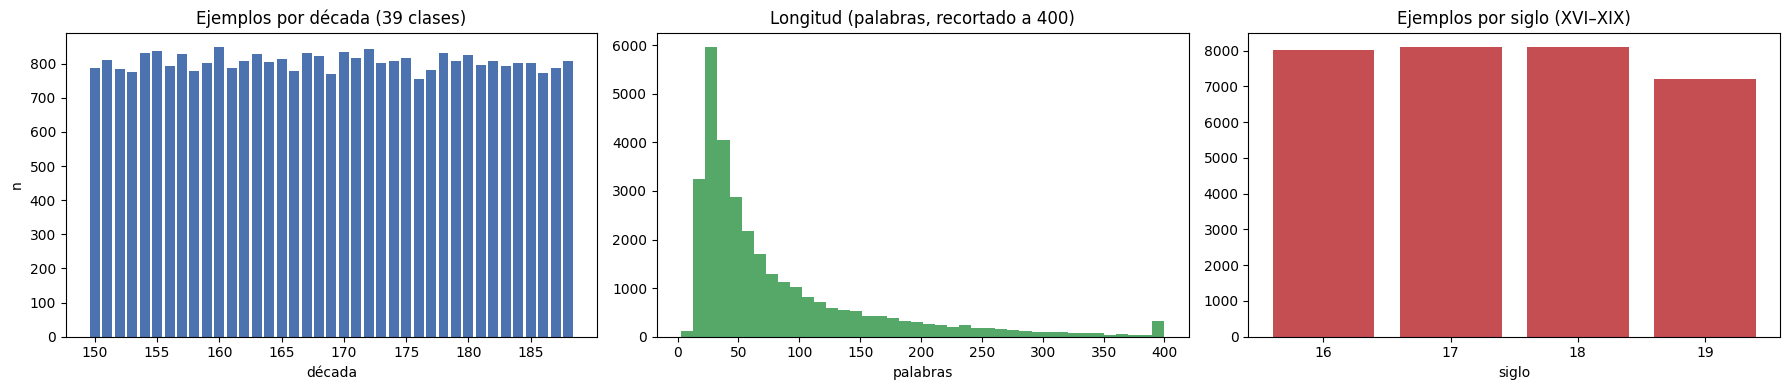

Clases balanceadas: 754–848 ejemplos/clase (ratio max/min = 1.12).
Longitud: mediana 50 palabras, p95 255 -> 384 tokens cubre ~95%.


In [8]:
import matplotlib.pyplot as plt

counts = corpus.train["decade"].value_counts().sort_index()
nw = corpus.train["text"].str.split().str.len()
sig = corpus.train["decade"].apply(decade_to_century).value_counts().sort_index()

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].bar(range(len(counts)), counts.values, color="#4C72B0")
ax[0].set_xticks(range(0, len(counts), 5))
ax[0].set_xticklabels([str(counts.index[i]) for i in range(0, len(counts), 5)])
ax[0].set_title("Ejemplos por década (39 clases)"); ax[0].set_xlabel("década"); ax[0].set_ylabel("n")
ax[1].hist(nw.clip(upper=400), bins=40, color="#55A868")
ax[1].set_title("Longitud (palabras, recortado a 400)"); ax[1].set_xlabel("palabras")
ax[2].bar([str(s) for s in sig.index], sig.values, color="#C44E52")
ax[2].set_title("Ejemplos por siglo (XVI–XIX)"); ax[2].set_xlabel("siglo")
plt.tight_layout(); plt.show()

print(f"Clases balanceadas: {counts.min()}–{counts.max()} ejemplos/clase "
      f"(ratio max/min = {counts.max()/counts.min():.2f}).")
print(f"Longitud: mediana {nw.median():.0f} palabras, p95 {nw.quantile(0.95):.0f} -> 384 tokens cubre ~95%.")


### 1.2 Inspección del ruido OCR

Medimos qué tipo de ruido domina el corpus. Esto **falsa** una intuición común: las ligaduras
históricas (long-s `ſ`, `ﬁ`) son **raras** (<1%); lo que abunda son **dobles espacios** y **cortes
de palabra con guion**. Por eso la augmentación realista del entrenamiento imitó *esos* artefactos
(no ligaduras), y por eso el TF-IDF de caracteres (robusto a variaciones de superficie) ayuda.


In [9]:
raw = corpus.train["text"].astype(str)
pct_double = raw.str.contains("  ", regex=False).mean()
pct_hyphen = raw.str.contains(r"-\s*\n", regex=True).mean()
pct_longs = raw.str.contains("ſ", regex=False).mean()
pct_lig = raw.str.contains(r"[ﬁﬂﬃﬄæœ]", regex=True).mean()

print(f"Dobles espacios : {pct_double*100:5.1f}%")
print(f"Corte con guion : {pct_hyphen*100:5.1f}%")
print(f"long-s (ſ)      : {pct_longs*100:5.1f}%")
print(f"Ligaduras (ﬁ..) : {pct_lig*100:5.1f}%")

print("\nEjemplos con long-s / ligaduras (texto crudo) y su normalización:")
ej = raw[raw.str.contains("ſ", regex=False)].head(2).tolist()
for e in ej:
    crudo = e[:140].replace("\n", " ")
    print("  crudo :", crudo, "...")
    print("  limpio:", preprocess_for_transformer(e)[:140], "...\n")


Dobles espacios :  52.2%
Corte con guion :  53.7%
long-s (ſ)      :   0.7%
Ligaduras (ﬁ..) :   0.0%

Ejemplos con long-s / ligaduras (texto crudo) y su normalización:
  crudo :  Dinci.znemo plus iuris, zc.vtin:l.nemo pP.f.deres, d em⸗ tido mo lean temudos Et eſt ratio quía cf  Shi ¡ 1) alí obligatiõe virivel fideiuſ ...
  limpio: Dinci.znemo plus iuris, zc.vtin:l.nemo pP.f.deres, d em⸗ tido mo lean temudos Et est ratio quía cf Shi ¡ 1) alí obligatione virivel fideiuss ...

  crudo :  el rey: ſeñaladamente que ouieſſe la  guarda de los reynos don enrrique,  con la reyna y ella que criaſſe al rey  v lo tuuieſſe en ſu guard ...
  limpio: el rey: señaladamente que ouiesse la guarda de los reynos don enrrique, con la reyna y ella que criasse al rey v lo tuuiesse en su guarda:x  ...



## 2. Preprocesamiento — dos limpiezas, una por familia de modelo

El proyecto usa **dos** representaciones del texto a propósito; cada modelo rinde mejor con su limpieza.

| | Transformer (DL) | TF-IDF (clásico) |
|---|---|---|
| Función | `preprocess_for_transformer` | `clean_for_tfidf_words` / `clean_for_tfidf_chars` |
| Casing | **se conserva** | a minúsculas |
| Dígitos | **se conservan** | se eliminan |
| Puntuación | **se conserva** | frontera de n-grama (chars) / fuera (words) |
| Stopwords | no se tocan | se quitan (lista mínima) |

**¿Por qué NO lowercase ni quitar puntuación para el transformer?** El tokenizer subword fue
preentrenado sobre texto natural; las mayúsculas y la puntuación son contexto útil, y la señal
histórica (ortografía de época) importa más que una limpieza agresiva.

**¿Por qué SÍ quitar dígitos para el TF-IDF?** En este corpus los números son casi siempre ruido de
referencias bibliográficas OCR (folios, páginas), no señal de década → inflan el vocabulario.

**¿Por qué sin stemming?** Destruiría formas históricas (`auia`, `efta`, `vueftra`) que son
justamente la señal de época que queremos.

**¿Por qué char_wb (2–4)?** Los n-gramas de caracteres son **robustos al OCR**: `esta` y `eſta`
comparten casi todos sus trigramas tras normalizar, así que el clásico no se rompe ante grafías raras.


## 3. Split holdout 90/10 (seed=42 — canónico)

Estratificado por década con `seed=42`: produce **las mismas filas** que el split con el que se
entrenaron los modelos DL. Por eso reusar modelos ya entrenados y medirlos en este holdout **no
introduce fuga** — el holdout nunca estuvo en su entrenamiento.


In [10]:
idx_tr, idx_va = stratified_split(corpus, val_size=0.10, seed=SEED)
y_idx = corpus.y_train_idx
texts = corpus.train["text_clean"].values   # para el DL (transformer)
raw_text = corpus.train["text"].values       # crudo, para la limpieza TF-IDF del legacy
X_tr_txt, X_va_txt = texts[idx_tr], texts[idx_va]
X_tr_raw, X_va_raw = raw_text[idx_tr], raw_text[idx_va]
y_tr, y_va = y_idx[idx_tr], y_idx[idx_va]
print("Train:", len(idx_tr), "| Holdout:", len(idx_va))


Train: 28262 | Holdout: 3141


## 4. Componente A — clásico TF-IDF + features de estilo + LogReg

Reproduce el modelo de la Entrega 1 (Kaggle 0.296): `char_wb(2,4)` + `word(1,2)` + 7 features de
estilo escaladas, con `LogisticRegression(C=4.0, solver=saga, class_weight=balanced)`.

**Caché:** ajustar el LogReg saga sobre ~227K features tarda ~2.5 h y dominaba el runtime. Como es
determinista sobre el split canónico, se **recarga** desde el dataset `legacy-tfidf` y solo se hace
`predict_proba` (segundos). Sin caché, se entrena una vez y se guarda.


In [11]:
%%time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

USE_NUMERIC_FEATS = True


def legacy_features(tfidf_word, tfidf_char, scaler, raw_texts, fit=False):
    '''Limpieza correcta para TF-IDF (la que dio 0.296) sobre texto CRUDO + features de estilo.'''
    w = [clean_for_tfidf_words(t) for t in raw_texts]
    c = [clean_for_tfidf_chars(t) for t in raw_texts]
    mats = ([tfidf_word.fit_transform(w), tfidf_char.fit_transform(c)] if fit
            else [tfidf_word.transform(w), tfidf_char.transform(c)])
    if scaler is not None:
        nf = numeric_style_feats(raw_texts)
        mats.append(csr_matrix(scaler.fit_transform(nf) if fit else scaler.transform(nf)))
    return hstack(mats).tocsr()


def extract_legacy(obj):
    '''Acepta un dict directo o el bundle final (con legacy_component).'''
    leg = obj.get("legacy_component", obj)
    return leg["tfidf_word"], leg["tfidf_char"], leg.get("scaler"), leg["classifier"]


if LEGACY_CACHE:
    print("Recargando legacy cacheado (sin reentrenar):", LEGACY_CACHE)
    tfidf_word, tfidf_char, scaler, legacy_clf = extract_legacy(joblib.load(LEGACY_CACHE))
else:
    print("Sin caché -> entrenando LogReg saga (lento, ~2.5h). Se guardará para reusar.")
    tfidf_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=3, max_df=0.9,
                                 max_features=80_000, sublinear_tf=True)
    tfidf_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=4,
                                 max_features=200_000, sublinear_tf=True)
    scaler = StandardScaler() if USE_NUMERIC_FEATS else None
    X_tr = legacy_features(tfidf_word, tfidf_char, scaler, X_tr_raw, fit=True)
    legacy_clf = LogisticRegression(C=4.0, max_iter=2000, solver="saga",
                                    class_weight="balanced", random_state=SEED)
    legacy_clf.fit(X_tr, y_tr)
    joblib.dump({"tfidf_word": tfidf_word, "tfidf_char": tfidf_char, "scaler": scaler,
                 "classifier": legacy_clf}, f"{OUT_DIR}/legacy_tfidf.joblib", compress=3)

X_va = legacy_features(tfidf_word, tfidf_char, scaler, X_va_raw, fit=False)
proba_legacy_val = legacy_clf.predict_proba(X_va)
metrics_legacy = compute_metrics(y_va, proba_legacy_val.argmax(1))
print_metrics(metrics_legacy, "LEGACY (holdout)")


Recargando legacy cacheado (sin reentrenar): /kaggle/input/datasets/diegoamolano/legacy-tfidf/modelo_final.joblib
[LEGACY (holdout)] F1-macro 0.2824 | acc 0.2853 | dist 3.48 | <=1dec 46.5% | <=2dec 59.7% | inter-siglo 26.1%
CPU times: user 4.76 s, sys: 152 ms, total: 4.91 s
Wall time: 6.26 s


## 5. Componente B — ensemble DL multi-task (xlm-roberta-large + BETO + xlm-roberta-base)

El bundle guardado trae la lista de modelos fine-tuneados y sus pesos de ensemble. Para cada uno se
reconstruye el `MultiTaskClassifier`, se recargan los pesos y se infiere con **ventana deslizante**
(promedio de logits sobre las ventanas de cada texto largo), y luego se promedian con `combine_proba`.

**¿Por qué multi-task siglo+década?** El siglo es una señal fácil (4 clases) que regulariza el
encoder compartido y reduce errores inter-siglo. **¿Por qué ensemble?** RoBERTa multilingüe y BERT
español (BETO) cometen errores distintos; promediarlos baja la varianza.


In [12]:
dl_bundle_path = next((p for p in CANDIDATE_BUNDLES if os.path.exists(p)), None)
assert dl_bundle_path is not None, (
    "No se encontró bundle DL. Monta de input el dataset del large (modelo-final-dl-large) y el de "
    "los modelos reusados (modelo-final-dl), o ajusta DL_INPUT_DIRS."
)
dl_bundle = joblib.load(dl_bundle_path)
print("Bundle DL:", dl_bundle_path, "| version:", dl_bundle.get("version"),
      "| val_f1:", round(dl_bundle.get("val_f1_macro", float('nan')), 4))


def _resolve_dir(d):
    if os.path.isdir(d):
        return d
    base = os.path.basename(d.rstrip("/"))
    for root in DL_INPUT_DIRS:
        cand = os.path.join(root, base)
        if os.path.isdir(cand):
            return cand
    raise FileNotFoundError(f"No encuentro la carpeta del modelo: {d} (basename {base})")


def dl_proba(bundle, texts):
    probs, weights = [], []
    for m in bundle["models"]:
        mdir = _resolve_dir(m["dir"])
        tok = AutoTokenizer.from_pretrained(mdir, use_fast=True)
        model = load_multitask(mdir, use_century=m.get("use_century", True))
        p = predict_logits_sliding(model, tok, list(texts),
                                   max_length=bundle.get("max_length", 384), return_proba=True)
        probs.append(p)
        weights.append(m.get("weight", 1.0))
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return combine_proba(probs, weights)


Bundle DL: /kaggle/input/datasets/diegoamolano/modelo-final-dl-large/modelo_final.joblib | version: 11_xlmr_large_ensemble | val_f1: 0.3133


In [13]:
%%time
proba_dl_val = dl_proba(dl_bundle, X_va_txt)
metrics_dl = compute_metrics(y_va, proba_dl_val.argmax(1))
print_metrics(metrics_dl, "DL ensemble (holdout)")


Token indices sequence length is longer than the specified maximum sequence length for this model (531 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (531 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (568 > 512). Running this sequence through the model will result in indexing errors


[DL ensemble (holdout)] F1-macro 0.3133 | acc 0.3161 | dist 2.77 | <=1dec 50.5% | <=2dec 65.2% | inter-siglo 20.4%
CPU times: user 7min 43s, sys: 5.59 s, total: 7min 49s
Wall time: 8min 13s


## 6. Ensemble híbrido + mejora segura (calibración del blend)

El blend de la entrega anterior era **aritmético**: `p = w·p_dl + (1−w)·p_legacy`, con `w` óptimo por
barrido en el holdout (salió `w=0.30`, F1 0.3374).

**Mejora barata sin reentrenar (esta iteración):** el LogReg con `class_weight=balanced` produce
probabilidades más *planas* que el softmax del DL, así que sumarlas crudas no es óptimo. Probamos un
**blend en espacio logarítmico (producto de expertos) con temperatura por componente**:

`p ∝ softmax( w·log(p_dl)/T_dl + (1−w)·log(p_legacy)/T_leg )`

Se busca `(w, T_dl, T_leg)` en el holdout. Para no sobreajustar, son solo **2–3 escalares globales**
(no umbrales por clase). **Regla de adopción:** se queda con el mejor método solo si **supera** el
aritmético `w=0.30`; si no, hace *fallback* al aritmético → el envío **nunca empeora**.


In [14]:
from sklearn.metrics import f1_score


def blend_proba(p_dl, p_leg, mode, w, T_dl=1.0, T_leg=1.0, eps=1e-9):
    if mode == "arith":
        return w * p_dl + (1 - w) * p_leg
    # log / geométrico (producto de expertos) con temperatura por componente
    z = w * (np.log(p_dl + eps) / T_dl) + (1 - w) * (np.log(p_leg + eps) / T_leg)
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def f1_of(proba):
    return f1_score(y_va, proba.argmax(1), average="macro", zero_division=0)


# (a) baseline aritmético
ws = np.linspace(0.0, 1.0, 41)
arith = [(float(w), f1_of(blend_proba(proba_dl_val, proba_legacy_val, "arith", w))) for w in ws]
best_arith_w, best_arith_f1 = max(arith, key=lambda x: x[1])

# (b) log + temperatura por componente
Ts = [0.5, 0.75, 1.0, 1.5, 2.0]
best_log = {"w": None, "T_dl": None, "T_leg": None, "f1": -1.0}
for w in ws:
    for T_dl in Ts:
        for T_leg in Ts:
            f1 = f1_of(blend_proba(proba_dl_val, proba_legacy_val, "log", w, T_dl, T_leg))
            if f1 > best_log["f1"]:
                best_log = {"w": float(w), "T_dl": T_dl, "T_leg": T_leg, "f1": float(f1)}

print(f"Aritmético  : w={best_arith_w:.2f}                 -> F1 holdout {best_arith_f1:.4f}")
print(f"Log+temp    : w={best_log['w']:.2f} T_dl={best_log['T_dl']} T_leg={best_log['T_leg']} -> F1 holdout {best_log['f1']:.4f}")

# (c) regla de adopción con piso garantizado
if best_log["f1"] > best_arith_f1 + 1e-6:
    CHOSEN = {"mode": "log", "w": best_log["w"], "T_dl": best_log["T_dl"], "T_leg": best_log["T_leg"]}
    chosen_f1 = best_log["f1"]
    print(f"\n-> Se ADOPTA el blend log+temp (mejora +{best_log['f1']-best_arith_f1:.4f} sobre el aritmético).")
else:
    CHOSEN = {"mode": "arith", "w": best_arith_w}
    chosen_f1 = best_arith_f1
    print("\n-> El log+temp NO supera al aritmético: fallback al aritmético (piso garantizado).")


def final_blend(p_dl, p_leg):
    return blend_proba(p_dl, p_leg, **CHOSEN)


print("Método final:", CHOSEN, "| F1 holdout:", round(chosen_f1, 4))
print(f"Componentes  -> legacy {metrics_legacy['f1_macro']:.4f} | DL {metrics_dl['f1_macro']:.4f} "
      f"| híbrido {chosen_f1:.4f}  (ganancia vs mejor componente "
      f"{chosen_f1 - max(metrics_legacy['f1_macro'], metrics_dl['f1_macro']):+.4f})")


Aritmético  : w=0.30                 -> F1 holdout 0.3374
Log+temp    : w=0.38 T_dl=0.5 T_leg=0.75 -> F1 holdout 0.3383

-> Se ADOPTA el blend log+temp (mejora +0.0009 sobre el aritmético).
Método final: {'mode': 'log', 'w': 0.375, 'T_dl': 0.5, 'T_leg': 0.75} | F1 holdout: 0.3383
Componentes  -> legacy 0.2824 | DL 0.3133 | híbrido 0.3383  (ganancia vs mejor componente +0.0250)


### 6.1 Diagnóstico por década y siglo

¿Dónde acierta y dónde falla el híbrido? Las décadas tempranas (1500s) son fáciles (F1 0.4–0.8);
las 1600s–1790s se desploman (F1 ~0.1–0.3). Como las clases están **balanceadas**, esto es
**confusabilidad** entre décadas vecinas, no escasez de datos.


In [15]:
proba_hyb_val = final_blend(proba_dl_val, proba_legacy_val)
pred_leg, pred_dl, pred_hyb = proba_legacy_val.argmax(1), proba_dl_val.argmax(1), proba_hyb_val.argmax(1)


def _per_class_f1(y_true, y_pred, k):
    return f1_score(y_true == k, y_pred == k, zero_division=0)


rows = []
for k in range(NUM_DECADES):
    n = int((y_va == k).sum())
    if n == 0:
        continue
    dec = IDX_TO_DECADE[k]
    rows.append({"decada": dec, "siglo": decade_to_century(dec), "n": n,
                 "f1_legacy": round(_per_class_f1(y_va, pred_leg, k), 3),
                 "f1_dl": round(_per_class_f1(y_va, pred_dl, k), 3),
                 "f1_hibrido": round(_per_class_f1(y_va, pred_hyb, k), 3)})
diag = pd.DataFrame(rows)
print("F1 medio por siglo (legacy / DL / híbrido):")
print(diag.groupby("siglo")[["f1_legacy", "f1_dl", "f1_hibrido"]].mean().round(3).to_string())
print("\nDécadas más débiles del híbrido:")
print(diag.nsmallest(8, "f1_hibrido")[["decada", "n", "f1_legacy", "f1_dl", "f1_hibrido"]].to_string(index=False))


F1 medio por siglo (legacy / DL / híbrido):
       f1_legacy  f1_dl  f1_hibrido
siglo                              
16         0.508  0.513       0.540
17         0.170  0.190       0.216
18         0.232  0.282       0.289
19         0.214  0.264       0.304

Décadas más débiles del híbrido:
 decada  n  f1_legacy  f1_dl  f1_hibrido
    165 81      0.094  0.142       0.097
    160 85      0.107  0.153       0.174
    166 78      0.122  0.203       0.175
    169 77      0.169  0.166       0.200
    161 79      0.163  0.211       0.215
    172 84      0.154  0.231       0.221
    163 83      0.204  0.155       0.228
    186 77      0.075  0.219       0.229


## 7. Inferencia final sobre `eval.csv` + submission

Se reusa el método de blend elegido (`CHOSEN`). El legacy usa el texto crudo; el DL, el `text_clean`.


In [16]:
test_texts = corpus.eval_["text_clean"].tolist()   # DL (transformer)
test_raw = corpus.eval_["text"].values              # crudo, para el TF-IDF del legacy

X_te = legacy_features(tfidf_word, tfidf_char, scaler, test_raw, fit=False)
proba_legacy_test = legacy_clf.predict_proba(X_te)


In [17]:
%%time
proba_dl_test = dl_proba(dl_bundle, test_texts)
proba_final = final_blend(proba_dl_test, proba_legacy_test)
pred_decade = np.array([IDX_TO_DECADE[i] for i in proba_final.argmax(1)])

sub_path = write_submission(corpus.eval_["id"].values, pred_decade, f"{OUT_DIR}/submission.csv")
print("Submission ->", sub_path, "| filas:", len(pred_decade), "| décadas únicas:", len(set(pred_decade)))


Token indices sequence length is longer than the specified maximum sequence length for this model (576 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (576 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (558 > 512). Running this sequence through the model will result in indexing errors


Submission -> /kaggle/working/submission.csv | filas: 3490 | décadas únicas: 39
CPU times: user 8min 32s, sys: 4.21 s, total: 8min 36s
Wall time: 8min 36s


## 8. Persistencia del modelo final

Se guarda `modelo_final.joblib` con el componente legacy (vectores + clasificador) y la referencia
al bundle DL + el método de blend elegido — suficiente para reproducir las predicciones.


In [18]:
final_payload = {
    "version": "final_hibrido_legacy_dl",
    "blend": CHOSEN,
    "legacy_component": {
        "tfidf_char": tfidf_char, "tfidf_word": tfidf_word, "classifier": legacy_clf,
        "scaler": scaler, "use_numeric_feats": bool(scaler is not None),
        "val_f1_macro": float(metrics_legacy["f1_macro"]),
    },
    "dl_component": {
        "bundle_path": dl_bundle_path, "version": dl_bundle.get("version"),
        "models": [{"name": m["name"], "dir": m["dir"], "weight": m.get("weight", 1.0)} for m in dl_bundle["models"]],
        "val_f1_macro": float(metrics_dl["f1_macro"]),
    },
    "ensemble_val_f1_macro": float(chosen_f1),
    "num_decades": NUM_DECADES, "idx_to_decade": IDX_TO_DECADE, "seed": SEED,
}
joblib.dump(final_payload, f"{OUT_DIR}/modelo_final.joblib", compress=3)
print("Saved:", f"{OUT_DIR}/modelo_final.joblib")

from IPython.display import FileLink, display
for name in ("submission.csv", "modelo_final.joblib"):
    path = f"{OUT_DIR}/{name}"
    if os.path.exists(path):
        print(f"{name} ({os.path.getsize(path)/1e6:.1f} MB)")
        display(FileLink(path))


Saved: /kaggle/working/modelo_final.joblib
submission.csv (0.0 MB)


/kaggle/working/submission.csv

modelo_final.joblib (70.1 MB)


/kaggle/working/modelo_final.joblib

## 9. Evidencia de iteración (rúbrica 5.2)

| # | Cambio principal | Modelo preentrenado | F1 holdout | Kaggle |
|---|---|---|---|---|
| E1 | TF-IDF char_wb + word + stacking (clásico) | — | 0.275 (val) | 0.296 |
| NB09 | XLM-R-base fine-tune, CE plana | xlm-roberta-base | 0.288 | 0.29130 |
| NB07 | ensemble DL multi-task (XLM-R-base + BETO) | + BETO | 0.3085 | 0.30276 |
| NB08 | **híbrido** clásico + DL base, blend w=0.30 | idem | 0.3305 | 0.31805 |
| NB11 | + xlm-roberta-large (reusa NB07) | xlm-roberta-large | 0.3133 (ens) | 0.31996 |
| NB08(DL=11) | híbrido clásico + DL large, blend aritmético | idem | 0.3374 | 0.32951 |
| **Final** | **+ blend calibrado (log+temp) sin reentrenar — 7.º puesto** | idem | **0.3383** | **0.33810** |

### Hipótesis verificadas / falseadas (lo que guió las decisiones)

- **El error es ordinal y de corta distancia.** ~50% de los aciertos caen a ≤1 década y ~65% a ≤2.
  Por eso se añadió la cabeza de siglo (multi-task) y se mide la distancia ordinal, no solo el F1.
- **Falseada — el label smoothing gaussiano ayuda.** Bajó el F1 exacto (0.24→0.20): empujaba masa a
  décadas vecinas y diluía la clase correcta → se volvió a **CE plana**.
- **Falseada — aumentar ligaduras OCR ayuda.** Las ligaduras son <1% del corpus real (ver EDA 1.2);
  inyectarlas creaba desajuste train/eval. Se cambió a ruido **realista** (dobles espacios, cortes
  con guion), que es el que sí abunda.
- **Verificada — el large estaba subentrenado en NB11.** La curva mostró el loss aún cayendo con el
  LR ya decaído a ~0. NB12 (más épocas + Gutenberg) se diseñó para corregirlo, pero **no se alcanzó a
  entrenar para esta entrega**; el modelo final usa el large de NB11 (mejor DL disponible).
- **Datos externos (Gutenberg, dominio público):** propuestos y filtrados (dedup vs eval/holdout,
  tope por década), pero cubren sobre todo décadas tempranas — donde el modelo **ya** es fuerte — y no
  las 1600s–1790s, que son las débiles. Por eso quedaron **fuera del modelo final** (ver
  `referencias_externas.md`).
- **Verificada — el híbrido es una palanca reusable.** Combinar el clásico (robusto al OCR) con el DL
  (semántico) sube de forma estable, con piso garantizado (w=0 ⇒ legacy).
- **Verificada — calibrar el blend ayuda.** El blend log/geométrico con temperatura por componente
  (`w=0.375, T_dl=0.5, T_leg=0.75`) superó al aritmético y, pese a un margen mínimo en holdout
  (0.3374→0.3383), rindió **+0.0086 en Kaggle** (0.32951→0.33810). Agudizar el DL (`T_dl=0.5`) antes
  de mezclarlo con el clásico (más plano) fue lo que más aportó.

> **Caveat honesto:** `w`/`T` se eligen en el holdout. En esta corrida el blend calibrado dio
> 0.3383 en holdout y **0.33810 en Kaggle** (público): generalizó incluso algo mejor que el holdout,
> y la regla de adopción con piso garantiza que nunca quede por debajo del blend aritmético.

## 10. Resumen del pipeline

1. **Carga + EDA** → 39 clases balanceadas, textos cortos, ruido OCR de superficie.
2. **Doble preprocesamiento** → mínimo para el transformer, agresivo (sin dígitos/stopwords) para el TF-IDF.
3. **Split canónico** seed=42 → holdout limpio compartido con los modelos ya entrenados.
4. **Componente A (clásico):** TF-IDF char_wb+word + estilo + LogReg balanceado (cacheado).
5. **Componente B (DL):** ensemble multi-task xlm-roberta-large + BETO + xlm-roberta-base, inferencia
   con ventana deslizante.
6. **Híbrido:** blend calibrado en holdout (log+temperatura) con piso garantizado.
7. **Submission + persistencia** del `modelo_final.joblib`.

**Cumplimiento del enunciado:** 5.1 — el componente principal es DL con transferencia de aprendizaje
y modelos preentrenados; el clásico es complemento de robustez, no reemplazo. Datos de prueba nunca
se usan para entrenar (split limpio + dedup de externos). Entregables (5.2): este notebook,
`modelo_final.joblib` y `referencias_externas.md` (fuentes externas + uso de IA generativa).
